# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [3]:
# untuk plot Q-Q
import scipy.stats as stats

In [4]:
df_california = pd.read_csv('california_dataset.csv')

In [5]:
from sklearn.model_selection import train_test_split
# splitting terlebih dahulu


#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

In [6]:
# Assignment 1.a : lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup'] di california_dataset.csv
# Daftar nama kolom yang ingin Anda cek
len(df_california)

20640

In [7]:
len(df_california)-len(df_california.drop_duplicates())

0

In [8]:
df_california.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'house_price'],
      dtype='str')

In [15]:
kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

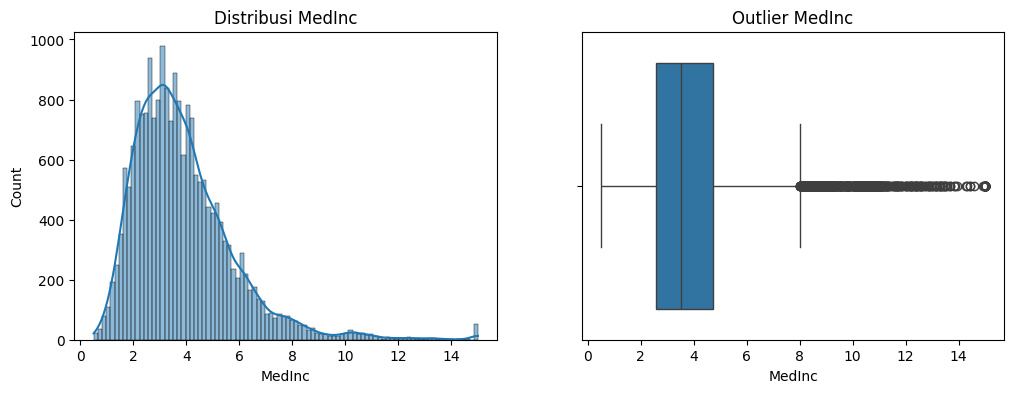

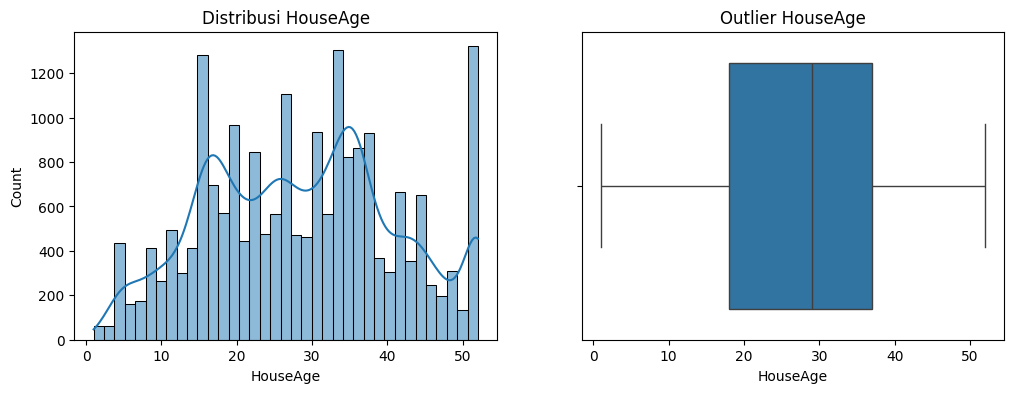

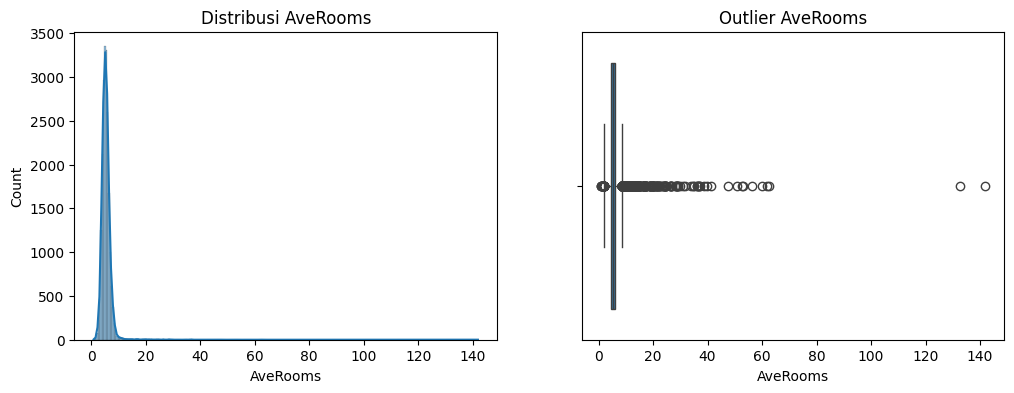

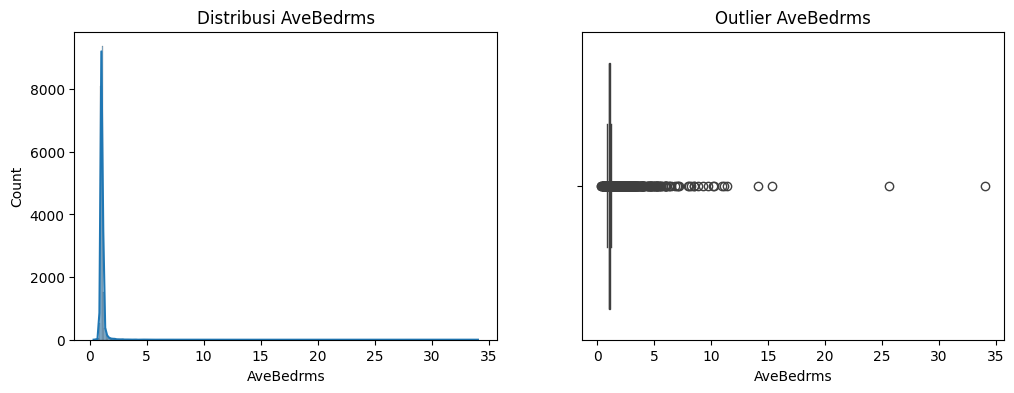

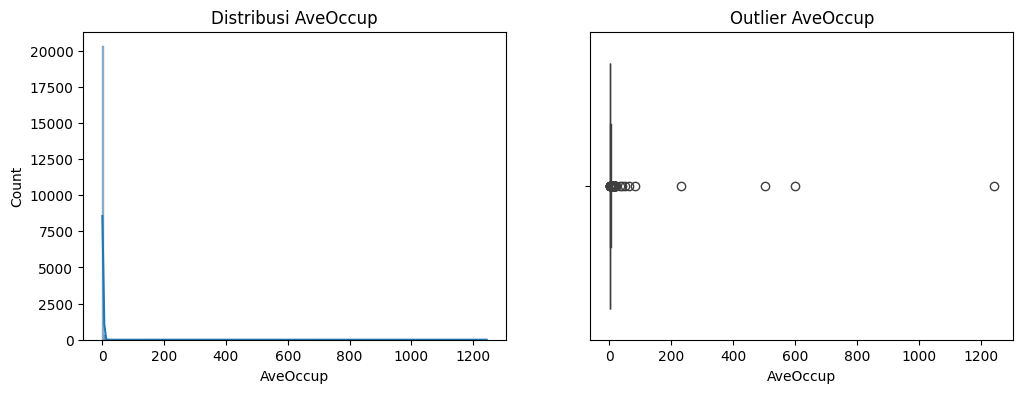

In [16]:
for col in kolom_kolom:
    
    plt.figure(figsize=(12,4))
    
    plt.subplot(1,2,1)
    sns.histplot(df_california[col], kde=True)
    plt.title(f'Distribusi {col}')
    
    plt.subplot(1,2,2)
    sns.boxplot(x=df_california[col])
    plt.title(f'Outlier {col}')
    
    plt.show()

### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

In [28]:
col = 'MedInc'

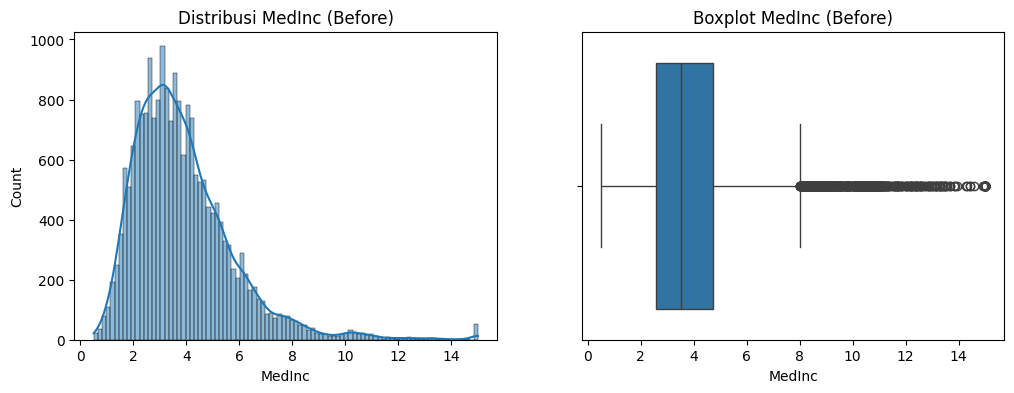

In [30]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df_california[col], kde=True)
plt.title(f'Distribusi {col} (Before)')

plt.subplot(1,2,2)
sns.boxplot(x=df_california[col])
plt.title(f'Boxplot {col} (Before)')

plt.show()

In [31]:
def find_outlier_boundary(df, variable):

    # Mari kita hitung batas luar yang merupakan outlier

    IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)

    lower_boundary = df[variable].quantile(0.25) - (IQR * 1.5)
    upper_boundary = df[variable].quantile(0.75) + (IQR * 1.5)

    return upper_boundary, lower_boundary

In [38]:
medinc_upper_limit, medinc_lower_limit = find_outlier_boundary(df_california, 'MedInc')

df_california_clean = df_california[
    (df_california['MedInc'] >= medinc_lower_limit) &
    (df_california['MedInc'] <= medinc_upper_limit)
]

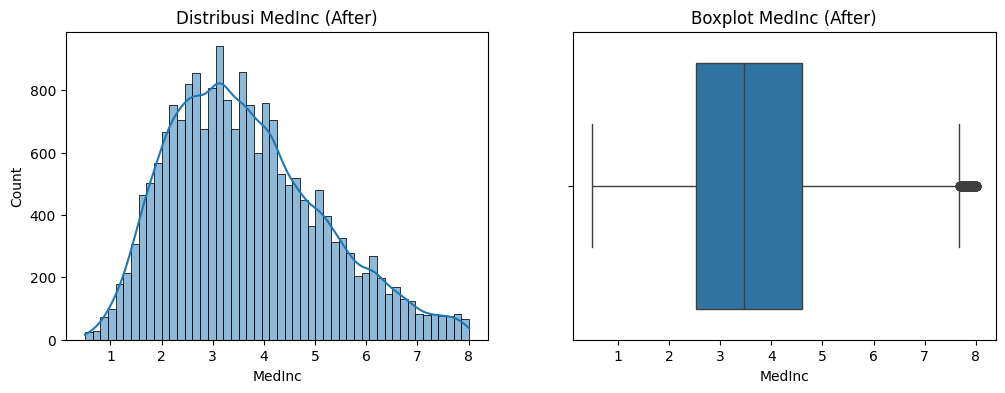

In [39]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df_california_clean['MedInc'], kde=True)
plt.title('Distribusi MedInc (After)')

plt.subplot(1,2,2)
sns.boxplot(x=df_california_clean['MedInc'])
plt.title('Boxplot MedInc (After)')

plt.show()

# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [ ]:
df_company = pd.read_csv('company.csv')

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [ ]:
from sklearn.model_selection import train_test_split
#Splitting terlebih dahulu

#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)

## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [85]:
df_company = pd.read_csv('company.csv')


In [98]:
df_company['Headquarters'].value_counts()

Headquarters
New York, NY                 33
San Francisco, CA            31
-1                           31
Chicago, IL                  23
Boston, MA                   19
Reston, VA                   14
Mc Lean, VA                  13
Westminster, CO              12
Cambridge, MA                10
Cambridge, United Kingdom    10
Vienna, VA                    8
Herndon, VA                   7
Bedford, MA                   7
Saint Louis, MO               7
Washington, DC                7
Denver, CO                    7
Arlington, VA                 7
San Jose, CA                  7
Woodbine, MD                  7
Basel, Switzerland            6
Mountain View, CA             6
Chantilly, VA                 6
San Rafael, CA                6
San Antonio, TX               6
Princeton, NJ                 5
Bellevue, WA                  5
Rockville, MD                 5
Bethesda, MD                  5
Fairfax, VA                   5
Springfield, MA               5
Houston, TX                

In [125]:
df_company['Headquarters'] = df_company['Headquarters'].replace("-1", np.nan)

In [127]:
from sklearn.model_selection import train_test_split
train_company, test_company = train_test_split(df_company, test_size = 0.2, random_state=42)

In [128]:
mode_headquarters = train_company[train_company['Headquarters'] != -1]['Headquarters'].mode()[0]

In [129]:
train_company['Headquarters'] = train_company['Headquarters'].fillna(mode_headquarters)
test_company['Headquarters'] = test_company['Headquarters'].fillna(mode_headquarters)

In [130]:
train_company['Headquarters'].value_counts()

Headquarters
New York, NY                 53
San Francisco, CA            28
Chicago, IL                  20
Boston, MA                   13
Mc Lean, VA                  12
Westminster, CO              10
Reston, VA                    9
Cambridge, MA                 8
Cambridge, United Kingdom     8
Bedford, MA                   7
Vienna, VA                    7
San Jose, CA                  7
Washington, DC                6
Woodbine, MD                  6
Mountain View, CA             6
Herndon, VA                   6
Saint Louis, MO               6
Arlington, VA                 6
Bethesda, MD                  5
Los Angeles, CA               5
San Antonio, TX               5
Denver, CO                    5
Chantilly, VA                 5
Annapolis Junction, MD        4
Austin, TX                    4
Pleasanton, CA                4
Houston, TX                   4
San Rafael, CA                4
Raleigh, NC                   4
Memphis, TN                   4
Orlando, FL                

# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [135]:
df_churn = pd.read_excel('TelcoCustomerChurn.xlsx')
df_churn.head(6)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes


In [137]:
# Mengganti "Yes" menjadi 1 dan "No" menjadi 0 dalam kolom "Churn"
df_churn['Churn'] = df_churn['Churn'].replace({'Yes': 1, 'No': 0})
df_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7,151.65,1


In [162]:
from sklearn.model_selection import train_test_split

train_churn, test_churn = train_test_split(
    df_churn,
    test_size = 0.2,
    random_state = 42
)

print("Jumlah data train:", len(train_churn))
print("Jumlah data test:", len(test_churn))

Jumlah data train: 5634
Jumlah data test: 1409


In [163]:
cols = [
'StreamingMovies',
'StreamingTV',
'TechSupport',
'DeviceProtection',
'OnlineBackup',
'OnlineSecurity',
'MultipleLines'
]

for col in cols:
    train_churn[col] = train_churn[col].replace('No internet service','No')
    test_churn[col] = test_churn[col].replace('No internet service','No')

## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [147]:
#Tulis jawaban
from sklearn.preprocessing import LabelEncoder


In [164]:
# Melakukan one-hot encoding pada kolom "gender"
# Kolom-kolom yang ingin di one-hot encoding
encode_ohe = ['gender'] #buat list nama-nama kolom yang ingin dilakukan OHE
train_churn = pd.get_dummies(train_churn, columns=encode_ohe, dtype=int)
test_churn = pd.get_dummies(test_churn, columns=encode_ohe, dtype=int)

In [165]:

yes_no_cols = ['Partner','Dependents']

for col in yes_no_cols:
    train_churn[col] = train_churn[col].map({'Yes':1,'No':0})
    test_churn[col] = test_churn[col].map({'Yes':1,'No':0})

In [166]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cols:
    train_churn[col] = le.fit_transform(train_churn[col])
    test_churn[col] = le.transform(test_churn[col])

In [167]:
mean_contract = train_churn.groupby('Contract')['Churn'].mean()

train_churn['Contract'] = train_churn['Contract'].map(mean_contract)
test_churn['Contract'] = test_churn['Contract'].map(mean_contract)

In [170]:
train_churn.head()

,customerID,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male
2142,4223-BKEOR,0,0,1,21,Yes,0,DSL,1,0,1,0,0,1,0.117987,No,Mailed check,64.85,1336.8,0,1,0
1623,6035-RIIOM,0,0,0,54,Yes,2,Fiber optic,0,1,0,0,1,1,0.028379,Yes,Bank transfer (automatic),97.2,5129.45,0,1,0
6074,3797-VTIDR,0,1,0,1,No,1,DSL,0,0,0,0,0,0,0.426533,Yes,Electronic check,23.45,23.45,1,0,1
1362,2568-BRGYX,0,0,0,4,Yes,0,Fiber optic,0,0,0,0,0,0,0.426533,Yes,Electronic check,70.2,237.95,1,0,1
6754,2775-SEFEE,0,0,1,0,Yes,2,DSL,1,1,0,1,0,0,0.028379,Yes,Bank transfer (automatic),61.9,NaN,0,0,1


In [169]:
test_churn.head()

,customerID,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male
185,1024-GUALD,0,1,0,1,No,1,DSL,0,0,0,0,0,0,0.426533,Yes,Electronic check,2025-08-24 00:00:00,2025-08-24 00:00:00,1,1,0
2715,0484-JPBRU,0,0,0,41,Yes,2,No,0,0,0,0,0,0,0.426533,Yes,Bank transfer (automatic),25.25,996.45,0,0,1
3825,3620-EHIMZ,0,1,1,52,Yes,0,No,0,0,0,0,0,0,0.028379,No,Mailed check,19.35,1031.7,0,1,0
1807,6910-HADCM,0,0,0,1,Yes,0,Fiber optic,0,0,1,0,0,0,0.426533,No,Electronic check,76.35,76.35,1,1,0
132,8587-XYZSF,0,0,0,67,Yes,0,DSL,0,0,0,1,0,0,0.028379,No,Bank transfer (automatic),50.55,3260-01-01 00:00:00,0,0,1


## Selesai :)